# Three-state model for tICA: is it noise or isnt it?

In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


In [2]:
trajectories_labels = ["tica_distances", "tica_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


In [29]:
MSM_LAG_NS = 200
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 30
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 1000
Submodel for tica_distances has 30 microstates.
Submodel for tica_dihedrals has 30 microstates.


Markov chain lag: 199.86 ns (1000 frames)


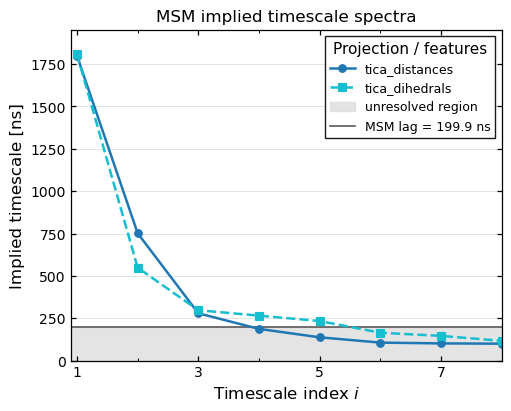

In [4]:
# ---------------------------------------------------------------------------
# Report-quality timescale spectrum plot: all MSMs in one panel

n_timescales = 8
msm_lag_ns = MSM_LAG_FRAMES * time_step_nanos
print(f"Markov chain lag: {msm_lag_ns:.2f} ns ({MSM_LAG_FRAMES} frames)")

# ---------------------------------------------------------------------------
# Figure

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    timescales_ns = np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos
    indices = np.arange(1, len(timescales_ns) + 1)


    ax.plot(
        indices,
        timescales_ns,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=rf"{name}"
    )

# ---------------------------------------------------------------------------
# MSM lag and threshold annotations

ax.axhspan(
    0,
    msm_lag_ns,
    color="0.85",
    alpha=0.7,
    zorder=0,
    label="unresolved region"
)

ax.axhline(
    msm_lag_ns,
    color="0.35",
    linestyle="-",
    linewidth=1.2,
    zorder=1,
    label=rf"MSM lag = {msm_lag_ns:.1f} ns"
)


# ---------------------------------------------------------------------------
# Axes formatting

ax.set_xlabel(r"Timescale index $i$")
ax.set_ylabel("Implied timescale [ns]")
ax.set_title("MSM implied timescale spectra")

ax.set_xlim(0.9, n_timescales)
ax.set_xticks(np.arange(1, n_timescales + 1, 2))
ax.set_xticks(np.arange(1, n_timescales + 1, 1), minor=True)

# Let the upper y-limit adapt to the data, threshold included
all_timescales = []

for name in trajectories_labels:
    msm = msm_dict[name]
    all_timescales.append(np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos)

all_timescales = np.concatenate(all_timescales)
finite_timescales = all_timescales[np.isfinite(all_timescales)]

ymax = max(
    np.nanmax(finite_timescales),
    #threshold_ns,
    msm_lag_ns
)

ax.set_ylim(0, 1.08 * ymax)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title="Projection / features",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)
# ---------------------------------------------------------------------------
# Save figure
#fig.savefig(
#    "../output_figures/msm_timescale_spectra_report.png",
#    dpi=600,
#    bbox_inches="tight"
#)
#fig.savefig(
#    "../output_figures/msm_timescale_spectra_report.pdf",
#    bbox_inches="tight"
#)
#plt.show()

## Three - state PCCA 

In [5]:
n_common = 3

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 3
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Project onto the timeseries (soft and hard)

In [9]:
#p1_timeseries_dict = {}
#p2_timeseries_dict = {}
pcca_probabilities_timeseries_dict = {}

hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]
    pcca_probabilities_timeseries_dict[name] = memberships[dtraj, :]

    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]
    p_macro2 = memberships[dtraj, 2]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    #p1_timeseries_dict[name] = p_macro1
    #p2_timeseries_dict[name] = p_macro2
    hard_assignments_timeseries_dict[name] = hard

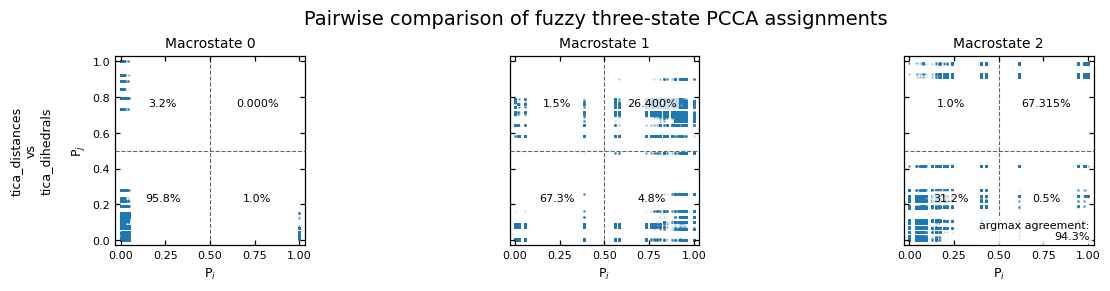

In [14]:
from itertools import combinations



def ensure_membership_matrix(p):
    """
    Ensure PCCA probabilities have shape (n_frames, n_macrostates).
    """
    p = np.asarray(p)

    if p.ndim != 2:
        raise ValueError(
            f"Expected a 2D array of shape (n_frames, n_macrostates), got shape {p.shape}"
        )

    # If stored as (n_macrostates, n_frames), transpose it.
    if p.shape[0] == 3 and p.shape[1] != 3:
        p = p.T

    return p


def quadrant_fractions(pi, pj, threshold=0.5):
    """
    Fractions of frames in the four regions defined by a threshold.

    x-axis: membership probability from model i
    y-axis: membership probability from model j
    """

    q00 = np.mean((pi < threshold) & (pj < threshold))
    q10 = np.mean((pi >= threshold) & (pj < threshold))
    q01 = np.mean((pi < threshold) & (pj >= threshold))
    q11 = np.mean((pi >= threshold) & (pj >= threshold))

    return {
        "q00": q00,
        "q10": q10,
        "q01": q01,
        "q11": q11,
    }


def add_quadrant_annotations(ax, quad, fontsize=8):
    """
    Add quadrant percentages in axes coordinates.
    """

    bbox = dict(
        boxstyle="round,pad=0.2",
        facecolor="white",
        alpha=0.75,
        edgecolor="none"
    )

    ax.text(
        0.25, 0.25,
        f"{100 * quad['q00']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )

    ax.text(
        0.75, 0.25,
        f"{100 * quad['q10']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )

    ax.text(
        0.25, 0.75,
        f"{100 * quad['q01']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )

    ax.text(
        0.75, 0.75,
        f"{100 * quad['q11']:.3f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize,
        bbox=bbox
    )


# ----------------------------------------------------
# Pairwise fuzzy PCCA membership comparison, 3 states
# ----------------------------------------------------

n_macrostates = 3
threshold = 0.5

pairs = list(combinations(trajectories_labels, 2))
n_pairs = len(pairs)

fig, axs = plt.subplots(
    nrows=n_pairs,
    ncols=n_macrostates,
    figsize=(4.0 * n_macrostates, 2.8 * n_pairs),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Make axs always 2D
axs = np.asarray(axs)
if axs.ndim == 1:
    axs = axs.reshape(n_pairs, n_macrostates)


for row, (name_i, name_j) in enumerate(pairs):

    Pi = ensure_membership_matrix(pcca_probabilities_timeseries_dict[name_i]) 
    Pj = ensure_membership_matrix(pcca_probabilities_timeseries_dict[name_j])

    if Pi.shape != Pj.shape:
        raise ValueError(
            f"Shape mismatch for {name_i} and {name_j}: {Pi.shape} vs {Pj.shape}"
        )

    if Pi.shape[1] != n_macrostates:
        raise ValueError(
            f"Expected {n_macrostates} macrostates, got {Pi.shape[1]} for {name_i}"
        )

    # Hard assignments, useful as a compact agreement diagnostic
    hard_i = np.argmax(Pi, axis=1)
    hard_j = np.argmax(Pj, axis=1)
    hard_agreement = np.mean(hard_i == hard_j)

    for k in range(n_macrostates):

        ax = axs[row, k]

        pi = Pi[:, k]
        pj = Pj[:, k]

        quad = quadrant_fractions(pi, pj, threshold=threshold)

        ax.scatter(
            pi,
            pj,
            s=0.7,
            alpha=0.03,
            rasterized=True
        )

        ax.axhline(
            threshold,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.6
        )

        ax.axvline(
            threshold,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.6
        )

        add_quadrant_annotations(ax, quad, fontsize=8)

        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.03, 1.03)
        ax.set_aspect("equal")

        if row == 0:
            ax.set_title(f"Macrostate {k}", fontsize=10)

        if k == 0:
            ax.set_ylabel(
                f"{name_i}\nvs\n{name_j}\n\nP$_j$",
                fontsize=9
            )

        if row == n_pairs - 1:
            ax.set_xlabel("P$_i$", fontsize=9)

        ax.tick_params(axis="both", labelsize=8)

    # Add pairwise hard-assignment agreement on the last panel of the row
    axs[row, -1].text(
        0.98,
        0.02,
        f"argmax agreement:\n{100 * hard_agreement:.1f}%",
        transform=axs[row, -1].transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )


fig.suptitle(
    "Pairwise comparison of fuzzy three-state PCCA assignments",
    fontsize=14
)

#plt.savefig(
##    "../output_figures/pairwise_pcca_membership_scatter_3state_report.pdf",
#    bbox_inches="tight"
#)

#plt.savefig(
#    "../output_figures/pairwise_pcca_membership_scatter_3state_report.png",
#    dpi=600,
#    bbox_inches="tight"
#)

plt.show()

In [12]:
# populations

distribution_dict = {}
for label in trajectories_labels:
    pcca_model = pcca_dict[label]
    distribution = pcca_model.coarse_grained_stationary_probability
    distribution_dict[label] = distribution

In [13]:
print("PCCA coarse-grained stationary distributions:")
for label, dist in distribution_dict.items():
    print(f"{label}: {dist}")

PCCA coarse-grained stationary distributions:
tica_distances: [0.01740067 0.25594054 0.72665879]
tica_dihedrals: [0.04684419 0.23358832 0.71956748]


- clearly, macrostate 3 is folded and macrostate 2 is unfolded.
- Macrostate 0 has very little population and no overlap, so it is difficult to say if it represents something physical.

Text(0.5, 0.98, 'probability of belonging to macrostate 0')

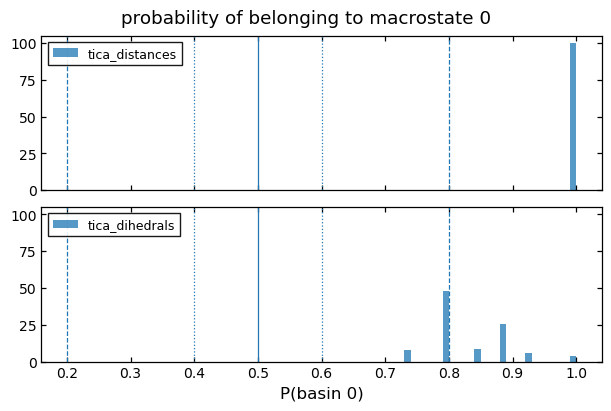

In [17]:
# Distribution of probability of belonging to macrostate 0


fig, axs = plt.subplots(
    nrows=len(trajectories_labels),
    ncols=1,
    figsize=(6, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

bins = np.linspace(0.5, 1, 51)

for ax, name in zip(axs, trajectories_labels):
    p = pcca_probabilities_timeseries_dict[name][:, 0]  # Probability of belonging to macrostate 0
    p = p[p>0.5] # restrict to assigned 

    ax.hist(
        p,
        bins=bins,
        density=True,
        alpha=0.75,
        label = name
    )

    ax.axvline(0.2, linestyle="--", linewidth=0.9)
    ax.axvline(0.4, linestyle=":", linewidth=0.9)
    ax.axvline(0.5, linestyle="-", linewidth=0.9)
    ax.axvline(0.6, linestyle=":", linewidth=0.9)
    ax.axvline(0.8, linestyle="--", linewidth=0.9)
    ax.legend(title="", frameon=True, fancybox=False, edgecolor="black", framealpha=0.9, loc="upper left")
    ax.set_ylabel("")

axs[-1].set_xlabel("P(basin 0)")
fig.suptitle("probability of belonging to macrostate 0")


In [18]:
def count_visits(assignments, state):
    in_state = assignments == state
    starts = np.where((~in_state[:-1]) & (in_state[1:]))[0] + 1

    if in_state[0]:
        starts = np.r_[0, starts]

    return len(starts)



for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]
    macro = 0  # Count visits to macrostate 0
    n_visits = count_visits(hard, macro)
    print(f"Number of visits to macrostate {macro} in {name}: {n_visits}")

Number of visits to macrostate 0 in tica_distances: 612
Number of visits to macrostate 0 in tica_dihedrals: 243


In [20]:
def dwell_times(assignments, state):
    in_state = assignments == state

    dwells = []
    current = 0

    for x in in_state:
        if x:
            current += 1
        else:
            if current > 0:
                dwells.append(current)
                current = 0

    if current > 0:
        dwells.append(current)

    return np.array(dwells)


for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]
    macro = 0  # Count visits to macrostate 0
    dt = dwell_times(hard, macro)
    print(f"Number of dwells in {name}:", len(dt))
    print(f"Mean dwell time in {name}:", np.mean(dt))
    print(f"Median dwell time in {name}:", np.median(dt))
    print(f"Max dwell time in {name}:", np.max(dt))

Number of dwells in tica_distances: 612
Mean dwell time in tica_distances: 25.952614379084967
Median dwell time in tica_distances: 1.0
Max dwell time in tica_distances: 4918
Number of dwells in tica_dihedrals: 243
Mean dwell time in tica_dihedrals: 201.46913580246914
Median dwell time in tica_dihedrals: 1.0
Max dwell time in tica_dihedrals: 9185


In [22]:
for name in trajectories_labels:
    T_macro = pcca_dict[name].coarse_grained_transition_matrix
    display(T_macro)

array([[7.82315814e-01, 1.75330340e-01, 4.23538457e-02],
       [1.23469050e-02, 9.08132573e-01, 7.95205223e-02],
       [8.63923893e-04, 2.81586527e-02, 9.70977423e-01]])

array([[7.55386194e-01, 2.08993956e-01, 3.56198494e-02],
       [4.77717896e-02, 8.65218053e-01, 8.70101572e-02],
       [4.16644429e-04, 3.01477435e-02, 9.69435612e-01]])

In [25]:
import networkx as nx
def plot_msm_network(
    T,
    ax=None,
    state_colors=None,
    pi=None,
    labels=None,
    top_k_per_state=3,
    min_prob=0.02,
    node_size_range=(800, 3500),
    edge_width_range=(1.0, 6.0),
    self_edges=False,
    seed=0,
):
    T = np.asarray(T, dtype=float)
    n = T.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    if labels is None:
        labels = {i: str(i) for i in range(n)}
    else:
        labels = {i: str(labels[i]) for i in range(n)}

    if state_colors is None:
        state_colors = ["lightgrey"] * n

    if pi is None:
        # left stationary distribution for row-stochastic T
        w, v = np.linalg.eig(T.T)
        idx = np.argmin(np.abs(w - 1))
        pi = np.real(v[:, idx])
        pi = np.abs(pi)
        pi = pi / pi.sum()

    # -----------------------------
    # Full graph for layout
    # -----------------------------
    G_full = nx.from_numpy_array(T, create_using=nx.DiGraph())

    pos = nx.spring_layout(
        G_full,
        weight="weight",
        k=5,
        seed=seed
    )

    # -----------------------------
    # Filter edges for plotting
    # -----------------------------
    G_plot = nx.DiGraph()
    G_plot.add_nodes_from(range(n))

    for i in range(n):
        probs = T[i].copy()

        if not self_edges:
            probs[i] = 0.0

        candidates = np.where(probs >= min_prob)[0]

        if len(candidates) > 0:
            strongest = candidates[np.argsort(probs[candidates])[-top_k_per_state:]]

            for j in strongest:
                G_plot.add_edge(i, j, weight=T[i, j])

    # -----------------------------
    # Node sizes
    # -----------------------------
    smin, smax = node_size_range
    if np.max(pi) > np.min(pi):
        node_sizes = smin + (pi - pi.min()) / (pi.max() - pi.min()) * (smax - smin)
    else:
        node_sizes = np.full(n, 0.5 * (smin + smax))

    # -----------------------------
    # Edge widths
    # -----------------------------
    edges = list(G_plot.edges())
    weights = np.array([G_plot[u][v]["weight"] for u, v in edges])

    if len(weights) > 0 and weights.max() > weights.min():
        wmin, wmax = edge_width_range
        edge_widths = wmin + (weights - weights.min()) / (weights.max() - weights.min()) * (wmax - wmin)
    elif len(weights) > 0:
        edge_widths = np.full(len(weights), np.mean(edge_width_range))
    else:
        edge_widths = []

    # -----------------------------
    # Draw
    # -----------------------------
    nx.draw_networkx_nodes(
        G_plot,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=state_colors,
        edgecolors="black",
        linewidths=1.5,
        alpha = 0.6
    )

    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        ax=ax,
        font_size=11,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G_plot,
        pos,
        ax=ax,
        edgelist=edges,
        width=edge_widths,
        arrows=True,
        arrowsize=15,
        arrowstyle="-|>",
        min_target_margin=25,
        min_source_margin=20,
        connectionstyle="arc3,rad=0.15",
        alpha=0.75
    )

    ax.set_title("Dominant macrostate transitions")
    ax.axis("off")

    return ax, G_plot, pos

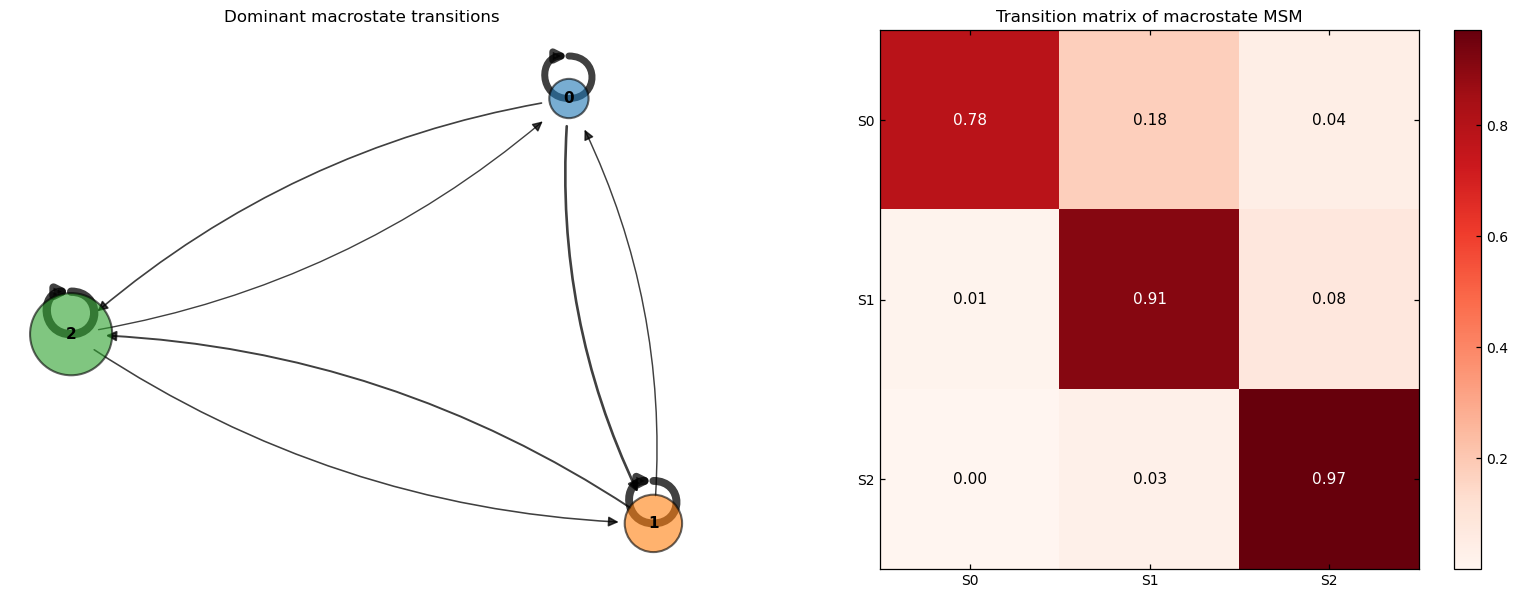

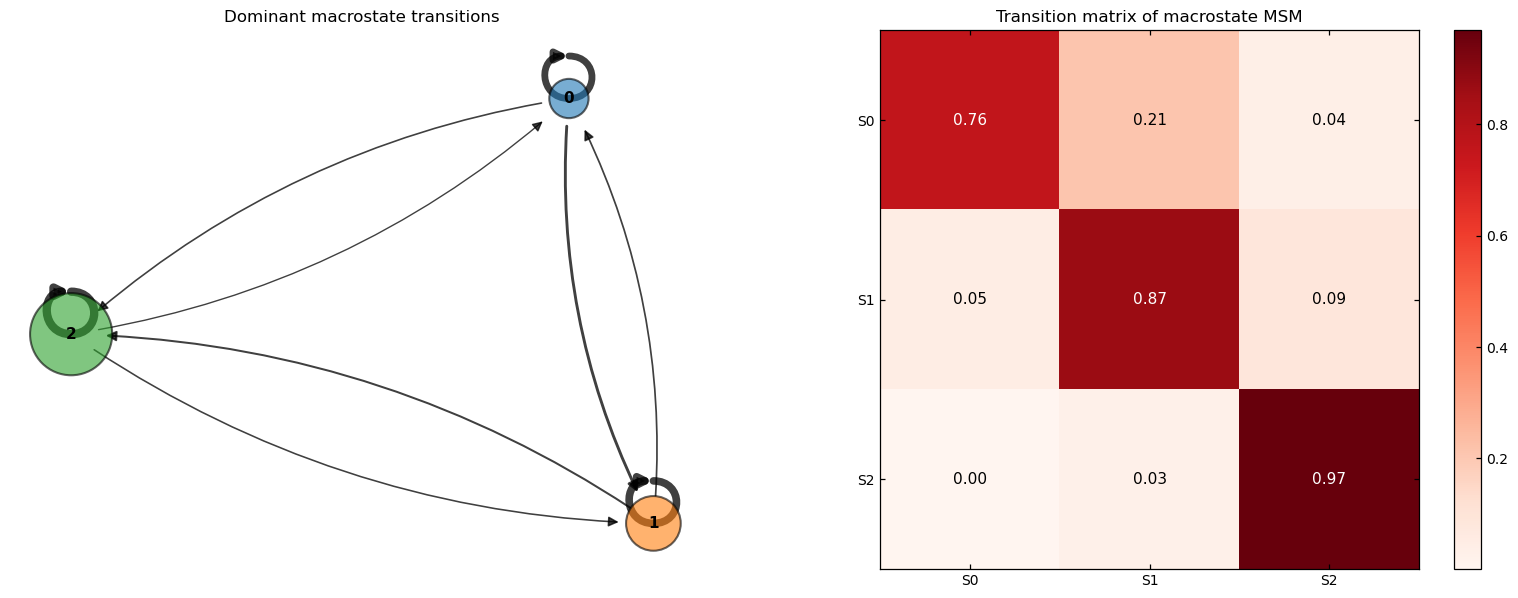

In [27]:
for name in trajectories_labels:
    T = pcca_dict[name].coarse_grained_transition_matrix


    fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 7))

    #############################
    # graph transition matrix

    ax = axs[0]
    ax, G_plot, pos = plot_msm_network(
        T,
        ax=ax,
        state_colors=["tab:blue", "tab:orange", "tab:green"],
        top_k_per_state=4,
        min_prob=0.,
        self_edges=False,
        seed=0
    )

    #############################
    im = axs[1].imshow(T, cmap="Reds")
    threshold = T.max() / 2

    for i in range(T.shape[0]):
        for j in range(T.shape[1]):
            axs[1].text(
                j, i,
                f"{T[i,j]:.2f}",
                ha="center",
                va="center",
                color="white" if T[i,j] > threshold else "black"
            )
    fig.colorbar(im, ax=axs[1])

    axs[1].set_xticks(np.arange(0, T.shape[0] , 1))
    axs[1].set_yticks(np.arange(0, T.shape[1] , 1))
    axs[1].set_xticklabels([f"S{i}" for i in range(T.shape[0])])
    axs[1].set_yticklabels([f"S{i}" for i in range(T.shape[1])])
    axs[1].set_title("Transition matrix of macrostate MSM")
    plt.show()

Seems like this metastable state describes a relaxation within the unfolded basin. So the next question is structural caracterization: can we find something that caracterizes it as distinct with respect to basin 1 - unfolded?

In [33]:
stride = 1000


distances_macro0_frames = np.where(hard_assignments_timeseries_dict["tica_distances"] == 0)[0][::stride]
print("Number of frames assigned to macrostate 0 in tica_distances:", len(distances_macro0_frames))
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "tica_distances_macro0_frames.npy")
np.save(filename, distances_macro0_frames)

Number of frames assigned to macrostate 0 in tica_distances: 16


In [36]:
stride = 4000
dihedrals_macro0_frames = np.where(hard_assignments_timeseries_dict["tica_dihedrals"] == 0)[0][::stride]
print("Number of frames assigned to macrostate 0 in tica_dihedrals:", len(dihedrals_macro0_frames))
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "tica_dihedrals_macro0_frames.npy")
np.save(filename, dihedrals_macro0_frames)

Number of frames assigned to macrostate 0 in tica_dihedrals: 13
